In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm

# import warnings

# # Suppress warnings for cleaner output
# warnings.filterwarnings("ignore")


In [2]:

def prepare_data_and_train_hmm(ticker, start_date, end_date, n_states=3):
    """
    Downloads data, calculates features, and trains a Gaussian HMM.
    """
    # 1. Download Data
    print(f"Downloading {ticker} data...")
    df = yf.download(ticker, start=start_date, end=end_date)
    
    if df.empty:
        raise ValueError("No data downloaded.")
    
    # 2. Feature Engineering
    # Calculate Log Returns
    df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # Calculate Rolling Volatility (20-day window)
    df['Volatility'] = df['LogReturn'].rolling(window=20).std()
    
    # Drop NaN values created by shifting and rolling
    df = df.dropna()
    
    # Prepare features for HMM: [LogReturn, Volatility]
    X = df[['LogReturn', 'Volatility']].values
    
    # 3. Train the HMM
    # GaussianHMM assumes features follow a Gaussian distribution per state
    model = hmm.GaussianHMM(
        n_components=n_states, 
        covariance_type='diag',  # Diagonal covariance for simplicity
        n_iter=1000,             # Max iterations for Baum-Welch
        tol=1e-4,                # Convergence tolerance
        random_state=42          # For reproducibility
    )
    
    print(f"Fitting HMM with {n_states} states...")
    model.fit(X)
    
    # 4. Predict States
    states = model.predict(X)
    df['Regime'] = states
    
    return df, model


In [12]:

# Example Usage
if __name__ == "__main__":
    data, trained_model = prepare_data_and_train_hmm(
        ticker="TSLA", 
        start_date="2023-01-01", 
        end_date="2024-12-31", 
        n_states=3
    )
    
    print("\nFirst 20 rows of detected regimes:")
    print(data[['Close', 'Regime']].head(20))
    
    # Analyze regime characteristics
    print("\nRegime Characteristics:")
    for i in range(3):
        mask = data['Regime'] == i
        mean_ret = data.loc[mask, 'LogReturn'].mean()
        mean_vol = data.loc[mask, 'Volatility'].mean()
        print(f"Regime {i}: Mean Return = {mean_ret:.6f}, Mean Vol = {mean_vol:.6f}")

[*********************100%***********************]  1 of 1 completed

Fitting HMM with 3 states...



First 20 rows of detected regimes:
Price            Close Regime
Ticker            TSLA       
Date                         
2023-02-01  181.410004      2
2023-02-02  188.270004      2
2023-02-03  189.979996      2
2023-02-06  194.759995      2
2023-02-07  196.809998      2
2023-02-08  201.289993      2
2023-02-09  207.320007      2
2023-02-10  196.889999      2
2023-02-13  194.639999      2
2023-02-14  209.250000      2
2023-02-15  214.240005      2
2023-02-16  202.039993      2
2023-02-17  208.309998      2
2023-02-21  197.369995      2
2023-02-22  200.860001      2
2023-02-23  202.070007      2
2023-02-24  196.880005      2
2023-02-27  207.630005      2
2023-02-28  205.710007      0
2023-03-01  202.770004      1

Regime Characteristics:
Regime 0: Mean Return = -0.000993, Mean Vol = 0.030867
Regime 1: Mean Return = 0.001081, Mean Vol = 0.030663
Regime 2: Mean Return = 0.009296, Mean Vol = 0.049776


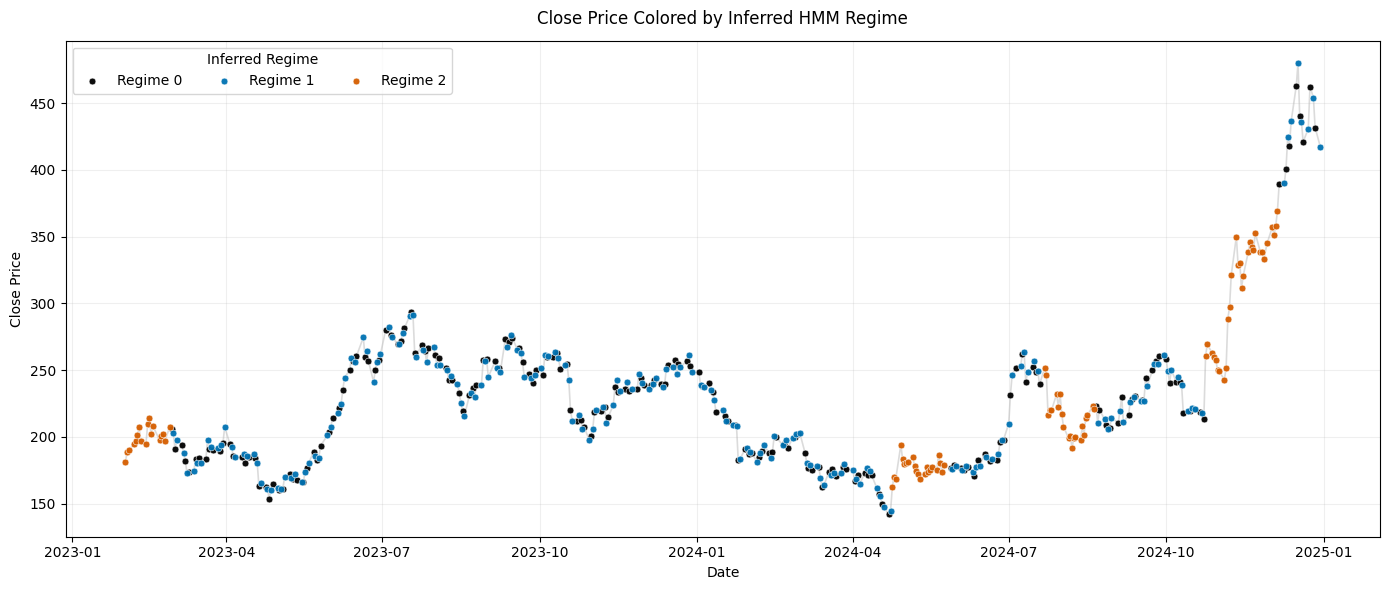

In [13]:
import matplotlib.pyplot as plt

# Plot close price with points colored by inferred HMM regime.
if "data" not in globals():
    raise RuntimeError("Run the training cell first so 'data' is available.")

close_series = data["Close"]
if isinstance(close_series, pd.DataFrame):
    close_series = close_series.iloc[:, 0]

regimes = sorted(data["Regime"].dropna().unique())

# High-contrast, colorblind-friendly palette (Paul Tol / Okabe-Ito style).
base_colors = ["#000000", "#0072B2", "#D55E00", "#009E73", "#CC79A7", "#F0E442", "#56B4E9", "#E69F00"]
colors = [base_colors[i % len(base_colors)] for i in range(len(regimes))]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(data.index, close_series, color="lightgray", linewidth=1.2, alpha=0.8, zorder=1)

for regime, color in zip(regimes, colors):
    mask = data["Regime"] == regime
    ax.scatter(
        data.index[mask],
        close_series[mask],
        s=24,
        color=color,
        edgecolors="white",
        linewidths=0.4,
        alpha=0.95,
        label=f"Regime {int(regime)}",
        zorder=2,
    )

ax.set_title("Close Price Colored by Inferred HMM Regime", pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.legend(title="Inferred Regime", ncols=min(3, len(regimes)))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()